# FCN3 Small Test Output Analysis

This notebook reads and visualizes the output from the small FCN3 Earth2Studio test.

Expected output:

```text
experiments/outputs/fcn3_small.zarr

In [58]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
zarr_path = Path("../outputs/fcn3_small.zarr")

print("Zarr path:", zarr_path.resolve())
print("Exists:", zarr_path.exists())

Zarr path: /cluster/home/siyan/github/WF-experiments/experiments/outputs/fcn3_small.zarr
Exists: True


In [59]:
ds = xr.open_zarr(zarr_path)
ds

/tmp/ipykernel_1899871/3815864296.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(zarr_path)


<xarray.Dataset> Size: 598MB
Dimensions:    (time: 1, lead_time: 2, lat: 721, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-01-01
  * lead_time  (lead_time) timedelta64[h] 16B 00:00:00 06:00:00
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables: (12/72)
    t150       (time, lead_time, lat, lon) float32 8MB ...
    q600       (time, lead_time, lat, lon) float32 8MB ...
    u700       (time, lead_time, lat, lon) float32 8MB ...
    z850       (time, lead_time, lat, lon) float32 8MB ...
    t925       (time, lead_time, lat, lon) float32 8MB ...
    q150       (time, lead_time, lat, lon) float32 8MB ...
    ...         ...
    q1000      (time, lead_time, lat, lon) float32 8MB ...
    u500       (time, lead_time, lat, lon) float32 8MB ...
    v50        (time, lead_time, lat, lon) float32 8MB ...
    z500       (time, lead_time, lat, lon) float32 8MB ...
    v10m       (time, lead_time, lat, lon) float32 8MB ...
    v700       (time, lead_time, lat, lon) float32 8MB ...

In [60]:
print("Dimensions:")
for k, v in ds.sizes.items():
    print(f"  {k}: {v}")

print("\nCoordinates:")
for c in ds.coords:
    print(f"  {c}: shape={ds[c].shape}, dtype={ds[c].dtype}")

print("\nData variables:")
for v in ds.data_vars:
    print(f"  {v}: shape={ds[v].shape}, dtype={ds[v].dtype}")

Dimensions:
  time: 1
  lead_time: 2
  lat: 721
  lon: 1440

Coordinates:
  lat: shape=(721,), dtype=float64
  lead_time: shape=(2,), dtype=timedelta64[h]
  lon: shape=(1440,), dtype=float64
  time: shape=(1,), dtype=datetime64[ns]

Data variables:
  t150: shape=(1, 2, 721, 1440), dtype=float32
  q600: shape=(1, 2, 721, 1440), dtype=float32
  u700: shape=(1, 2, 721, 1440), dtype=float32
  z850: shape=(1, 2, 721, 1440), dtype=float32
  t925: shape=(1, 2, 721, 1440), dtype=float32
  q150: shape=(1, 2, 721, 1440), dtype=float32
  t50: shape=(1, 2, 721, 1440), dtype=float32
  u50: shape=(1, 2, 721, 1440), dtype=float32
  v100: shape=(1, 2, 721, 1440), dtype=float32
  v100m: shape=(1, 2, 721, 1440), dtype=float32
  v150: shape=(1, 2, 721, 1440), dtype=float32
  z700: shape=(1, 2, 721, 1440), dtype=float32
  t100: shape=(1, 2, 721, 1440), dtype=float32
  v400: shape=(1, 2, 721, 1440), dtype=float32
  v200: shape=(1, 2, 721, 1440), dtype=float32
  q100: shape=(1, 2, 721, 1440), dtype=float32


In [61]:
import numpy as np

# Case 1: u/v are stored as separate data variables
if "u10" in ds.data_vars and "v10" in ds.data_vars:
    u_field = ds["u10"]
    v_field = ds["v10"]
    u_name, v_name = "u10", "v10"

elif "u10m" in ds.data_vars and "v10m" in ds.data_vars:
    u_field = ds["u10m"]
    v_field = ds["v10m"]
    u_name, v_name = "u10m", "v10m"

# Case 2: variables are stored in a variable-like coordinate
else:
    possible_var_dims = ["variable", "channel", "variables", "var"]

    found = False

    for dim in possible_var_dims:
        if dim in arr.dims and dim in ds.coords:
            names = [str(v) for v in ds[dim].values]

            if "u10" in names and "v10" in names:
                u_field = arr.sel({dim: "u10"})
                v_field = arr.sel({dim: "v10"})
                u_name, v_name = "u10", "v10"
                found = True
                break

            if "u10m" in names and "v10m" in names:
                u_field = arr.sel({dim: "u10m"})
                v_field = arr.sel({dim: "v10m"})
                u_name, v_name = "u10m", "v10m"
                found = True
                break

    if not found:
        raise ValueError(
            "Could not find 10 m wind variables. "
            f"Data variables are: {list(ds.data_vars)}. "
            f"Array dims are: {arr.dims}. "
            f"Coordinates are: {list(ds.coords)}."
        )

print("Selected wind variables:")
print("u component:", u_name)
print("v component:", v_name)

print("u_field:", u_field)
print("v_field:", v_field)

Selected wind variables:
u component: u10m
v component: v10m
u_field: <xarray.DataArray 'u10m' (time: 1, lead_time: 2, lat: 721, lon: 1440)> Size: 8MB
[2076480 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-01-01
  * lead_time  (lead_time) timedelta64[h] 16B 00:00:00 06:00:00
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
v_field: <xarray.DataArray 'v10m' (time: 1, lead_time: 2, lat: 721, lon: 1440)> Size: 8MB
[2076480 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-01-01
  * lead_time  (lead_time) timedelta64[h] 16B 00:00:00 06:00:00
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8


In [62]:
u_plot = u_field
v_plot = v_field

for dim in list(u_plot.dims):
    if dim not in ["lat", "lon"]:
        u_plot = u_plot.isel({dim: 0})
        v_plot = v_plot.isel({dim: 0})

print("u_plot dims:", u_plot.dims)
print("u_plot shape:", u_plot.shape)

print("v_plot dims:", v_plot.dims)
print("v_plot shape:", v_plot.shape)

u_plot dims: ('lat', 'lon')
u_plot shape: (721, 1440)
v_plot dims: ('lat', 'lon')
v_plot shape: (721, 1440)


In [63]:
wind_speed = np.sqrt(u_plot**2 + v_plot**2)
wind_speed.name = "wind_speed_10m"

plot_field = wind_speed
var_name = "10 m wind speed"

plot_field

<xarray.DataArray 'wind_speed_10m' (lat: 721, lon: 1440)> Size: 4MB
array([[4.6082263, 4.6020036, 4.610008 , ..., 4.606458 , 4.606835 ,
        4.607719 ],
       [4.6480083, 4.6413217, 4.648871 , ..., 4.640369 , 4.6405144,
        4.640651 ],
       [5.5080853, 5.5019712, 5.5026503, ..., 5.4982333, 5.505952 ,
        5.506946 ],
       ...,
       [5.589584 , 5.590259 , 5.591717 , ..., 5.587239 , 5.5951166,
        5.588944 ],
       [5.959158 , 5.9673   , 5.9667273, ..., 5.961684 , 5.960758 ,
        5.9599166],
       [6.2065725, 6.208084 , 6.205875 , ..., 6.210494 , 6.2077374,
        6.209056 ]], shape=(721, 1440), dtype=float32)
Coordinates:
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
    lead_time  timedelta64[s] 8B 00:00:00
    time       datetime64[ns] 8B 2024-01-01

In [64]:
import numpy as np
import xarray as xr

# If you already computed wind speed, keep it
# Example:
# wind_speed = np.sqrt(u_plot**2 + v_plot**2)
# wind_speed.name = "wind_speed_10m"

plot_field = wind_speed.copy()

# Reduce any extra dims (time, lead_time, batch, etc.) to the first slice
for dim in list(plot_field.dims):
    if dim not in ["lat", "lon"]:
        plot_field = plot_field.isel({dim: 0})

print(plot_field)
print("dims:", plot_field.dims)
print("shape:", plot_field.shape)

<xarray.DataArray 'wind_speed_10m' (lat: 721, lon: 1440)> Size: 4MB
array([[4.6082263, 4.6020036, 4.610008 , ..., 4.606458 , 4.606835 ,
        4.607719 ],
       [4.6480083, 4.6413217, 4.648871 , ..., 4.640369 , 4.6405144,
        4.640651 ],
       [5.5080853, 5.5019712, 5.5026503, ..., 5.4982333, 5.505952 ,
        5.506946 ],
       ...,
       [5.589584 , 5.590259 , 5.591717 , ..., 5.587239 , 5.5951166,
        5.588944 ],
       [5.959158 , 5.9673   , 5.9667273, ..., 5.961684 , 5.960758 ,
        5.9599166],
       [6.2065725, 6.208084 , 6.205875 , ..., 6.210494 , 6.2077374,
        6.209056 ]], shape=(721, 1440), dtype=float32)
Coordinates:
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
    lead_time  timedelta64[s] 8B 00:00:00
    time       datetime64[ns] 8B 2024-01-01
dims: ('lat', 'lon')
shape: (721, 1440)


In [65]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_wind_map(
    field,
    title,
    extent=None,
    cmap="viridis",
    vmin=None,
    vmax=None,
    figsize=(12, 6),
    add_tromso=False,
    coastline_resolution="110m",
):
    """
    field: xarray.DataArray with lat/lon coordinates
    extent: [lon_min, lon_max, lat_min, lat_max] or None
    """

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    else:
        ax.set_global()

    # Background / features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.coastlines(resolution=coastline_resolution, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)

    # Plot field
    mesh = ax.pcolormesh(
        field["lon"],
        field["lat"],
        field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    cbar = plt.colorbar(
        mesh,
        ax=ax,
        pad=0.02,
        shrink=0.45,      # controls length
        fraction=0.03,    # controls width
        aspect=18,        # controls shape
    )

    cbar.set_label("Wind speed\n(m/s)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    if add_tromso:
        tromso_lon, tromso_lat = 18.9553, 69.6492
        ax.plot(
            tromso_lon,
            tromso_lat,
            marker="*",
            markersize=10,
            transform=ccrs.PlateCarree(),
        )
        ax.text(
            tromso_lon + 0.08,
            tromso_lat + 0.03,
            "Tromsø",
            transform=ccrs.PlateCarree(),
            fontsize=10,
            weight="bold",
        )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [66]:
vmin = float(plot_field.min().values)
vmax = float(plot_field.max().values)

print("vmin =", vmin)
print("vmax =", vmax)

vmin = 0.005934928078204393
vmax = 27.122634887695312


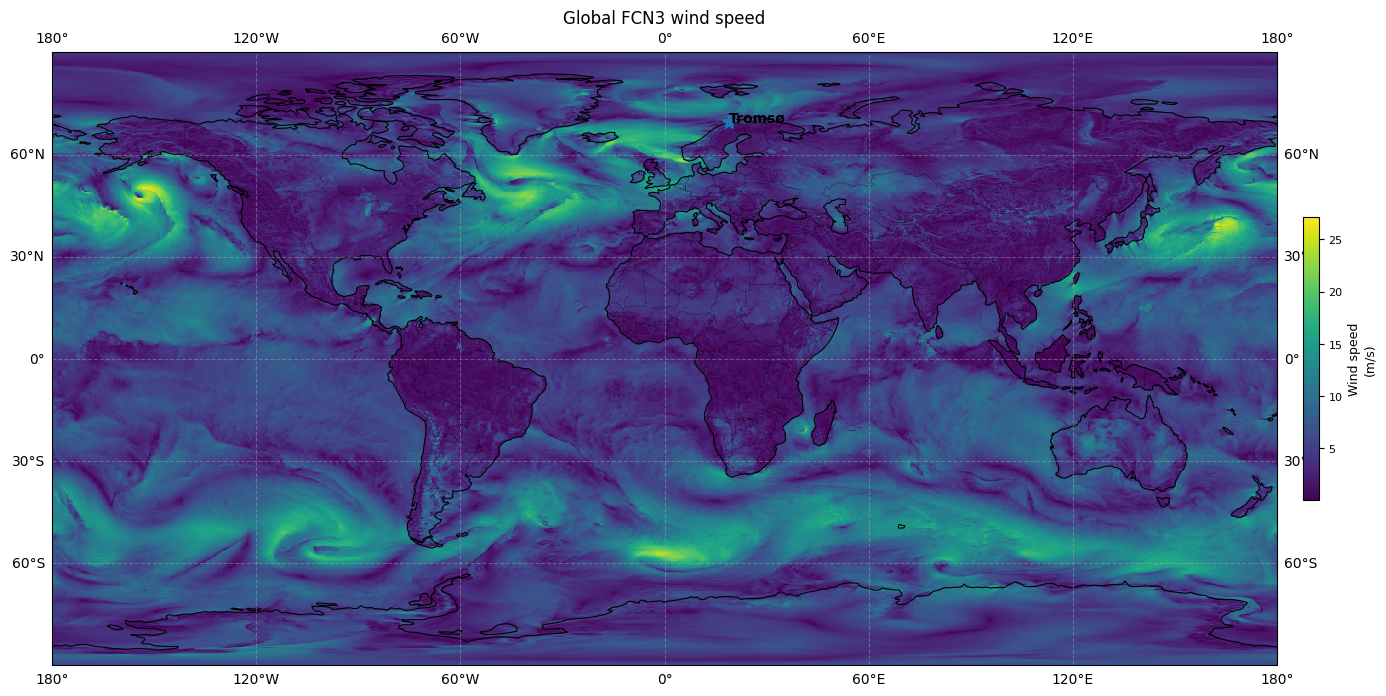

In [67]:
plot_wind_map(
    plot_field,
    title="Global FCN3 wind speed",
    extent=None,
    vmin=vmin,
    vmax=vmax,
    figsize=(14, 7),
    add_tromso=True,
    coastline_resolution="110m",
)

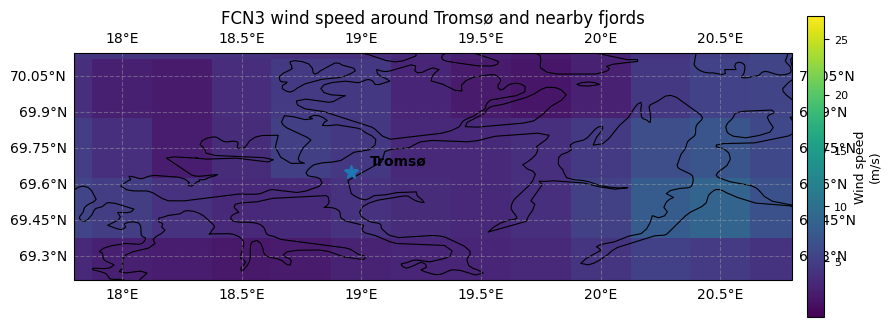

In [68]:
north_norway_extent = [5, 32, 64.5, 72.5]

plot_wind_map(
    plot_field,
    title="FCN3 wind speed around Tromsø and nearby fjords",
    extent=[17.8, 20.8, 69.2, 70.15],
    vmin=vmin,
    vmax=vmax,
    figsize=(9, 7),
    add_tromso=True,
    coastline_resolution="10m",
)